In [1]:
%pip install xgboost pandas scikit-learn matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


**1. Initial Setup and Data Loading**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

df = pd.read_csv('../data/Processed/cleaned_dataset.csv')

print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (1470, 45)


,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,41,1,1102,1,2,2,94,3,2,4,...,False,False,False,False,False,True,False,False,True,True
1,49,0,279,8,1,3,61,2,2,2,...,False,False,False,False,True,False,False,True,False,False
2,37,1,1373,2,2,4,92,2,1,3,...,True,False,False,False,False,False,False,False,True,True
3,33,0,1392,3,4,4,56,3,1,3,...,False,False,False,False,True,False,False,True,False,True
4,27,0,591,2,1,1,40,3,1,2,...,True,False,False,False,False,False,False,True,False,False


**2. Data Preparation**

In [3]:
# Convert boolean columns to integers
bool_cols = df.select_dtypes(include=['bool']).columns
df[bool_cols] = df[bool_cols].astype(int)

# Define Features (X) and Target (y)
X = df.drop('Attrition', axis=1)
y = df['Attrition']

# Split data into training and testing sets (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Data splitting completed.")

Data splitting completed.


**3. Baseline XGBoost Model**

In [4]:
# Initialize and train the baseline model
base_model = xgb.XGBClassifier(
    eval_metric='logloss', 
    random_state=42
)

base_model.fit(X_train, y_train)

# Predictions and Evaluation
y_pred = base_model.predict(X_test)

print("--- Baseline Model Performance ---")
print(classification_report(y_test, y_pred))

--- Baseline Model Performance ---
              precision    recall  f1-score   support

           0       0.87      0.97      0.92       247
           1       0.58      0.23      0.33        47

    accuracy                           0.85       294
   macro avg       0.72      0.60      0.62       294
weighted avg       0.82      0.85      0.82       294



**4. Hyperparameter Tuning**

In [5]:
# Define the parameter grid
param_grid = {
    'n_estimators': [100, 200, 500],
    'max_depth': [3, 4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'gamma': [0, 0.1, 0.2],
    'scale_pos_weight': [1, 3, 5] 
}

# Setup Randomized Search
random_search = RandomizedSearchCV(
    estimator=xgb.XGBClassifier(eval_metric='logloss'),
    param_distributions=param_grid,
    n_iter=20,
    scoring='f1',
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

# Fit the search
print("Starting Hyperparameter Tuning...")
random_search.fit(X_train, y_train)

print(f"Best Parameters: {random_search.best_params_}")

Starting Hyperparameter Tuning...
Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best Parameters: {'subsample': 0.7, 'scale_pos_weight': 5, 'n_estimators': 500, 'max_depth': 4, 'learning_rate': 0.01, 'gamma': 0.2, 'colsample_bytree': 0.9}


**5. Final Model Evaluation and Feature Importance**

--- Tuned Model Performance ---
              precision    recall  f1-score   support

           0       0.90      0.89      0.89       247
           1       0.45      0.47      0.46        47

    accuracy                           0.82       294
   macro avg       0.67      0.68      0.68       294
weighted avg       0.83      0.82      0.82       294



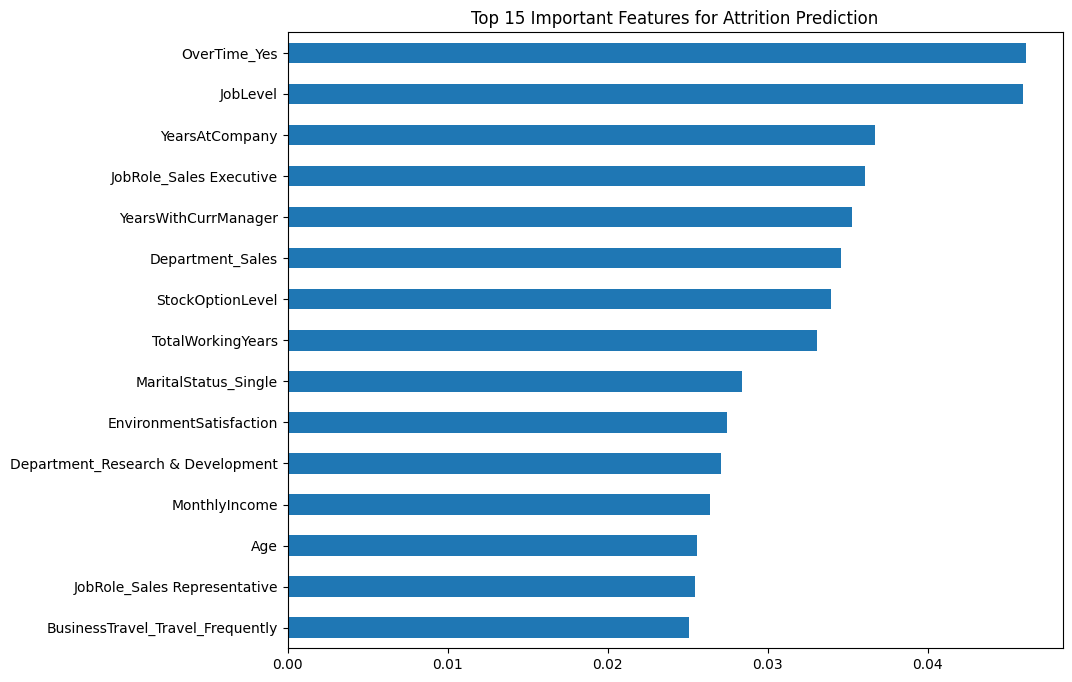

In [6]:
# Get the best model from search
best_model = random_search.best_estimator_

# Final Evaluation
y_final_pred = best_model.predict(X_test)
print("--- Tuned Model Performance ---")
print(classification_report(y_test, y_final_pred))

# Plot Feature Importance
plt.figure(figsize=(10, 8))
feat_importances = pd.Series(best_model.feature_importances_, index=X.columns)
feat_importances.nlargest(15).plot(kind='barh')
plt.title('Top 15 Important Features for Attrition Prediction')
plt.gca().invert_yaxis()
plt.show()

**6. Visualize XGBoost Decision Tree**

In [7]:
%pip install graphviz

Note: you may need to restart the kernel to use updated packages.


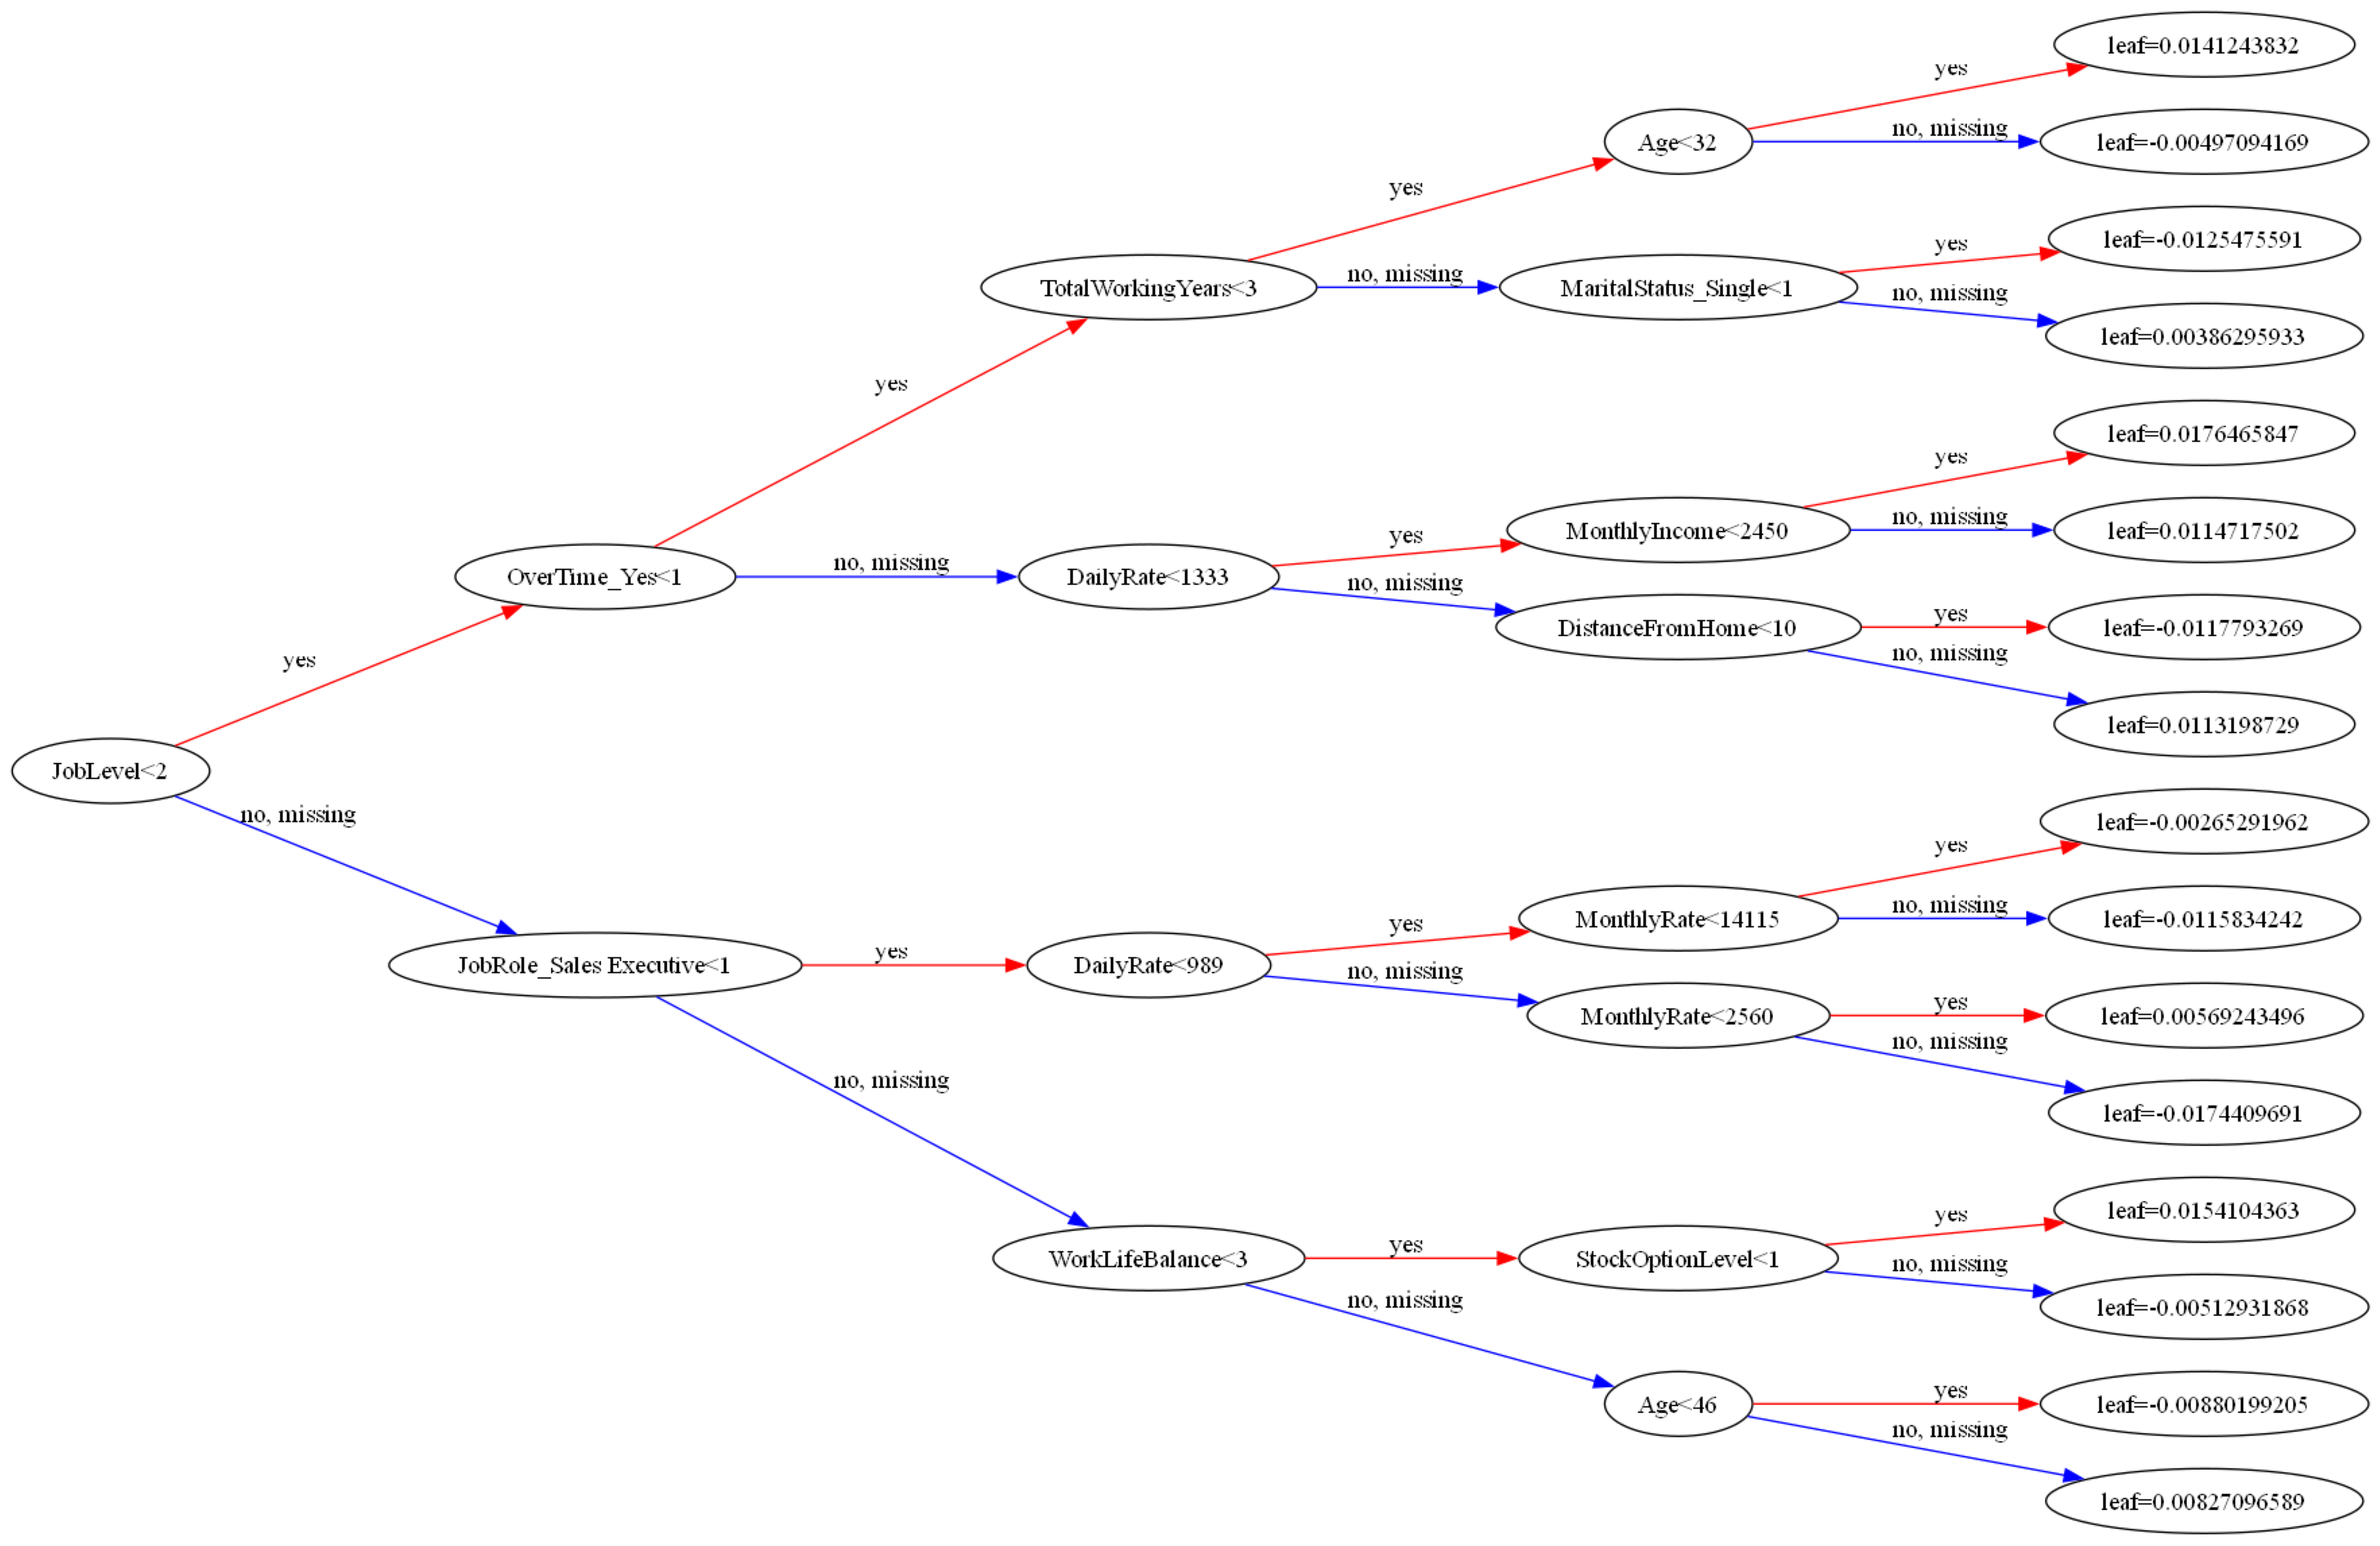

In [10]:
import xgboost as xgb
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(80, 40), dpi=100)

xgb.plot_tree(best_model, num_trees=0, ax=ax, rankdir='LR')

plt.savefig("xgboost_tree_high_res.png", bbox_inches='tight', dpi=300)

plt.show()